# Brain Tumor 3D Segmentation with MONAI SegRegNet Model
Purpose is to train a `SegRegNet` model to preform segmentation on Brain Tumor MRI images.  The dataset used for training is available from [medical decathlon](http://medicaldecathlon.com/) and has the following characteristics:
- **Target**: Glioma segmenation necrotic/active tumor and edema
- **Modality**: FLAIR, T1w, T1gd, and T2w
- **Size**: 750 4D volumes (484 Training and 266 Testing)
- **Source**: BraTS 2016 and 2017 datasets

A paper describing the dataset can be found at [Simpson et al, 2019](https://arxiv.org/abs/1902.09063)

----
<a name='startup_tasks'></a>
## 1.0 <span style='color:blue'>|</span> Common Start Up Tasks

<a name='import_packages'></a>
### 1.1 <span style='color:blue'>|</span> Import Required Packages and Libraries

In [1]:
import os, shutil, tempfile, time, random, gc, warnings, glob
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'        # Fixes a warning from PyTorch
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import List, Tuple, Dict, Optional, Literal
from dataclasses import dataclass
from pathlib import Path

from monai.apps import DecathlonDataset
from monai.config import print_config
from monai.data import DataLoader, decollate_batch
from monai.handlers.utils import from_engine
from monai.losses import DiceLoss
from monai.inferers import sliding_window_inference
from monai.metrics import DiceMetric
from monai.networks.nets import SegResNet
from monai.transforms import (
    Activations,
    Activationsd,
    AsDiscrete,
    AsDiscreted,
    Compose,
    Invertd,
    LoadImaged,
    MapTransform,
    NormalizeIntensityd,
    Orientationd,
    RandFlipd,
    RandScaleIntensityd,
    RandShiftIntensityd,
    RandSpatialCropd,
    Spacingd,
    EnsureTyped,
    EnsureChannelFirstd,
)

from monai.utils import set_determinism
import onnxruntime
from tqdm import tqdm

# Make plots have guidelines
plt.style.use('ggplot')

# Squash Python warnings
warnings.filterwarnings('ignore')

# Enable Python's Garbage Collector
gc.collect()

2026-03-02 18:20:17.570162309 [W:onnxruntime:Default, device_discovery.cc:211 DiscoverDevicesForPlatform] GPU device discovery failed: device_discovery.cc:91 ReadFileContents Failed to open file: "/sys/class/drm/card0/device/vendor"
<frozen importlib._bootstrap_external>:1325: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
2026-03-02 18:20:23.714134: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


752

<a name='global_variables'></a>
### 1.2 <span style='color:blue'>|</span> Declare Global Variables and Set Device

In [2]:
SEED = 42
ROOT_DIR = '../monai'
MAX_EPOCHS = 100
VAL_INTERVAL = 1
VAL_AMP = True
NUM_WORKERS = 4
ROI_SIZE = [128, 128, 64]

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

<a name='random_seed'></a>
### 1.3 <span style='color:blue'>|</span> Set Random Seed for Reproducibility
Not sure if all of these are required, but I have seen consistent results between runs

In [3]:
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
#set_determinism(SEED)

# When running on CuDNN backend, it is recommended to set these two options
torch.backends.cudnn.benchmark = True
torch.backends.cudnn.deterministic = False
torch.set_float32_matmul_precision('medium')

In [4]:
class ConvertToMultiChannelBasedOnBratsClassesd(MapTransform):
    '''
    Convert labels to multi channels based on brats classes:
    label 1 is the peritumoral edema
    label 2 is the GD-enhancing tumor
    label 3 is the necrotic and non-enhancing tumor core
    The possible classes are TC (Tumor core), WT (Whole tumor)
    and ET (Enhancing tumor).
    '''

    def __call__(self, data):
        d = dict(data)
        for key in self.keys:
            result = []
            # merge label 2 and label 3 to construct TC
            result.append(torch.logical_or(d[key] == 2, d[key] == 3))
            # merge labels 1, 2 and 3 to construct WT
            result.append(torch.logical_or(torch.logical_or(d[key] == 2, d[key] == 3), d[key] == 1))
            # label 2 is ET
            result.append(d[key] == 2)
            d[key] = torch.stack(result, axis=0).float()
        return d

In [5]:
train_transform = Compose(
    [
        # load 4 Nifti images and stack them together
        LoadImaged(keys=['image', 'label']),
        EnsureChannelFirstd(keys='image'),
        EnsureTyped(keys=['image', 'label']),
        ConvertToMultiChannelBasedOnBratsClassesd(keys='label'),
        Orientationd(keys=['image', 'label'], axcodes='RAS'),
        Spacingd(
            keys=['image', 'label'],
            pixdim=(1.0, 1.0, 1.0),
            mode=('bilinear', 'nearest'),
        ),
        RandSpatialCropd(keys=['image', 'label'], roi_size=ROI_SIZE, random_size=False),
        RandFlipd(keys=['image', 'label'], prob=0.5, spatial_axis=0),
        RandFlipd(keys=['image', 'label'], prob=0.5, spatial_axis=1),
        RandFlipd(keys=['image', 'label'], prob=0.5, spatial_axis=2),
        NormalizeIntensityd(keys='image', nonzero=True, channel_wise=True),
        RandScaleIntensityd(keys='image', factors=0.1, prob=1.0),
        RandShiftIntensityd(keys='image', offsets=0.1, prob=1.0),
    ]
)
val_transform = Compose(
    [
        LoadImaged(keys=['image', 'label']),
        EnsureChannelFirstd(keys='image'),
        EnsureTyped(keys=['image', 'label']),
        ConvertToMultiChannelBasedOnBratsClassesd(keys='label'),
        Orientationd(keys=['image', 'label'], axcodes='RAS'),
        Spacingd(
            keys=['image', 'label'],
            pixdim=(1.0, 1.0, 1.0),
            mode=('bilinear', 'nearest'),
        ),
        NormalizeIntensityd(keys='image', nonzero=True, channel_wise=True),
    ]
)

In [6]:
train_ds = DecathlonDataset(
    root_dir=ROOT_DIR,
    task='Task01_BrainTumour',
    transform=train_transform,
    section='training',
    download=False,
    cache_rate=0.0,
    num_workers=NUM_WORKERS,
)
train_loader = DataLoader(train_ds, batch_size=1, shuffle=True, num_workers=4)

val_ds = DecathlonDataset(
    root_dir=ROOT_DIR,
    task='Task01_BrainTumour',
    transform=val_transform,
    section='validation',
    download=False,
    cache_rate=0.0,
    num_workers=NUM_WORKERS,
)
val_loader = DataLoader(val_ds, batch_size=1, shuffle=False, num_workers=NUM_WORKERS)

image shape: torch.Size([4, 240, 240, 155])


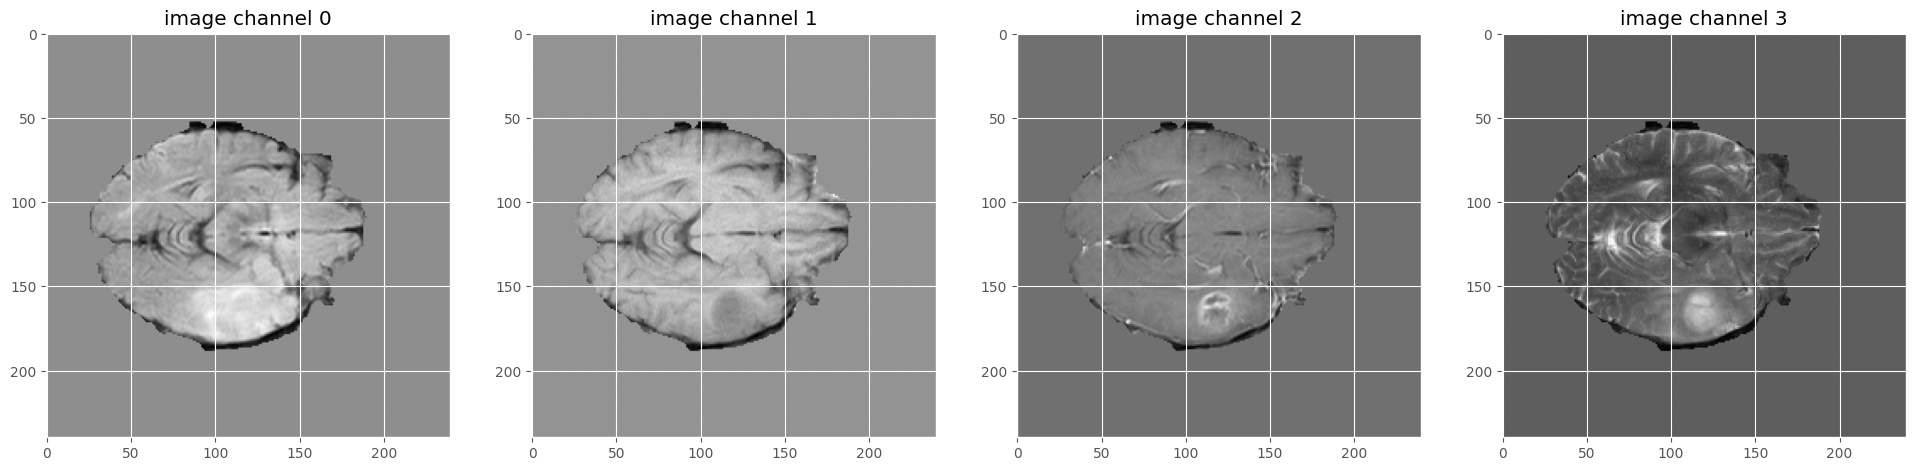

label shape: torch.Size([3, 240, 240, 155])


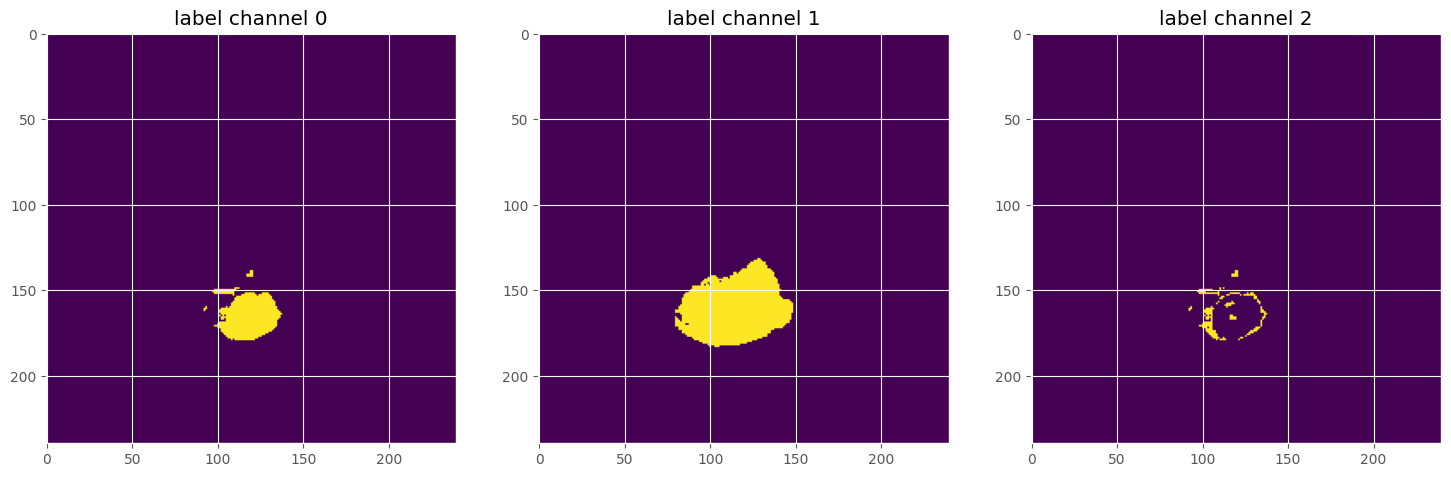

In [7]:
# Pick one image and visualize the different channels
val_data_example = val_ds[2]
print(f'image shape: {val_data_example['image'].shape}')
plt.figure('image', (24, 6))
for i in range(4):
    plt.subplot(1, 4, i + 1)
    plt.title(f'image channel {i}')
    plt.imshow(val_data_example['image'][i, :, :, 60].detach().cpu(), cmap='gray')
plt.show()

# Visualize the segmentation labels
print(f'label shape: {val_data_example['label'].shape}')
plt.figure('label', (18, 6))
for i in range(3):
    plt.subplot(1, 3, i + 1)
    plt.title(f'label channel {i}')
    plt.imshow(val_data_example['label'][i, :, :, 60].detach().cpu())
plt.show()

In [8]:
# standard PyTorch program style: create SegResNet, DiceLoss and Adam optimizer
model = SegResNet(
    blocks_down  = [1, 2, 2, 4],
    blocks_up    = [1, 1, 1],
    init_filters = 16,
    in_channels  = 4,
    out_channels = 3,
    dropout_prob = 0.2).to(DEVICE)

loss_function = DiceLoss(smooth_nr=0, smooth_dr=1e-5, squared_pred=True, to_onehot_y=False, sigmoid=True)
optimizer = torch.optim.Adam(model.parameters(), 1e-4, weight_decay=1e-5)
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=MAX_EPOCHS)

dice_metric = DiceMetric(include_background=True, reduction='mean')
dice_metric_batch = DiceMetric(include_background=True, reduction='mean_batch')

post_trans = Compose([Activations(sigmoid=True), AsDiscrete(threshold=0.5)])


# define inference method
def inference(input):
    def _compute(input):
        return sliding_window_inference(
            inputs = input,
            roi_size = ROI_SIZE,
            sw_batch_size = 4,
            predictor = model,
            overlap = 0.5,
        )

    if VAL_AMP:
        with torch.autocast('cuda'):
            return _compute(input)
    else:
        return _compute(input)


# use amp to accelerate training
scaler = torch.GradScaler('cuda')
# enable cuDNN benchmark
torch.backends.cudnn.benchmark = True

In [9]:
# Early stopping parameters
patience = 5
min_delta = 1e-4
best_metric = -1
best_metric_epoch = -1
early_stop_counter = 0
early_stop_triggered = False

best_metrics_epochs_and_time = [[], [], []]
epoch_loss_values = []
metric_values = []
metric_values_tc = []
metric_values_wt = []
metric_values_et = []

total_start = time.time()
for epoch in tqdm(range(MAX_EPOCHS), desc='Training Epochs'):
    epoch_start = time.time()
    print('-' * 10)
    print(f'epoch {epoch + 1}/{MAX_EPOCHS}')
    model.train()
    epoch_loss = 0
    step = 0
    for batch_data in train_loader:
        step_start = time.time()
        step += 1
        inputs, labels = (
            batch_data['image'].to(DEVICE),
            batch_data['label'].to(DEVICE),
        )
        optimizer.zero_grad()
        with torch.autocast('cuda'):
            outputs = model(inputs)
            loss = loss_function(outputs, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        epoch_loss += loss.item()

    lr_scheduler.step()
    epoch_loss /= step
    epoch_loss_values.append(epoch_loss)
    print(f'epoch {epoch + 1} average loss: {epoch_loss:.4f}')

    if (epoch + 1) % VAL_INTERVAL == 0:
        model.eval()
        with torch.no_grad():
            for val_data in val_loader:
                val_inputs, val_labels = (
                    val_data['image'].to(DEVICE),
                    val_data['label'].to(DEVICE),
                )
                val_outputs = inference(val_inputs)
                val_outputs = [post_trans(i) for i in decollate_batch(val_outputs)]
                dice_metric(y_pred=val_outputs, y=val_labels)
                dice_metric_batch(y_pred=val_outputs, y=val_labels)

            metric = dice_metric.aggregate().item()
            metric_values.append(metric)
            metric_batch = dice_metric_batch.aggregate()
            metric_tc = metric_batch[0].item()
            metric_values_tc.append(metric_tc)
            metric_wt = metric_batch[1].item()
            metric_values_wt.append(metric_wt)
            metric_et = metric_batch[2].item()
            metric_values_et.append(metric_et)
            dice_metric.reset()
            dice_metric_batch.reset()

            if metric > best_metric + min_delta:
                best_metric = metric
                best_metric_epoch = epoch + 1
                best_metrics_epochs_and_time[0].append(best_metric)
                best_metrics_epochs_and_time[1].append(best_metric_epoch)
                best_metrics_epochs_and_time[2].append(time.time() - total_start)
                torch.save(
                    model.state_dict(),
                    os.path.join(ROOT_DIR, 'best_metric_model.pth'),
                )
                print('saved new best metric model')
                early_stop_counter = 0  # reset counter on improvement
            else:
                early_stop_counter += 1  # no improvement -> increment counter

                print(f'current epoch: {epoch + 1} current mean dice: {metric:.4f}'
                    f' tc: {metric_tc:.4f} wt: {metric_wt:.4f} et: {metric_et:.4f}'
                    f'\nbest mean dice: {best_metric:.4f} at epoch: {best_metric_epoch}'
                    f'\nearly stop counter: {early_stop_counter}/{patience}'
                )

            # Check for early stopping trigger
            if early_stop_counter >= patience:
                print(f'\nEarly stopping triggered at epoch {epoch + 1}')
                early_stop_triggered = True
                break  # exit the epoch loop 

Training Epochs:   0%|                                         | 0/100 [00:00<?, ?it/s]

----------
epoch 1/100
epoch 1 average loss: 0.8565


Training Epochs:   1%|▎                             | 1/100 [02:01<3:20:06, 121.28s/it]

saved new best metric model
----------
epoch 2/100
epoch 2 average loss: 0.8218


Training Epochs:   2%|▌                             | 2/100 [04:02<3:17:51, 121.13s/it]

...

current epoch: 29 current mean dice: 0.7012 tc: 0.7606 wt: 0.8489 et: 0.4943
best mean dice: 0.7078 at epoch: 26
early stop counter: 3/5
----------
epoch 30/100
epoch 30 average loss: 0.4400


Training Epochs:  30%|████████                   | 30/100 [1:01:36<2:21:47, 121.54s/it]

current epoch: 30 current mean dice: 0.6594 tc: 0.7130 wt: 0.8066 et: 0.4588
best mean dice: 0.7078 at epoch: 26
early stop counter: 4/5
----------
epoch 31/100
epoch 31 average loss: 0.4191


Training Epochs:  30%|████████                   | 30/100 [1:03:37<2:28:27, 127.25s/it]

current epoch: 31 current mean dice: 0.6783 tc: 0.7246 wt: 0.8650 et: 0.4452
best mean dice: 0.7078 at epoch: 26
early stop counter: 5/5

Early stopping triggered at epoch 31


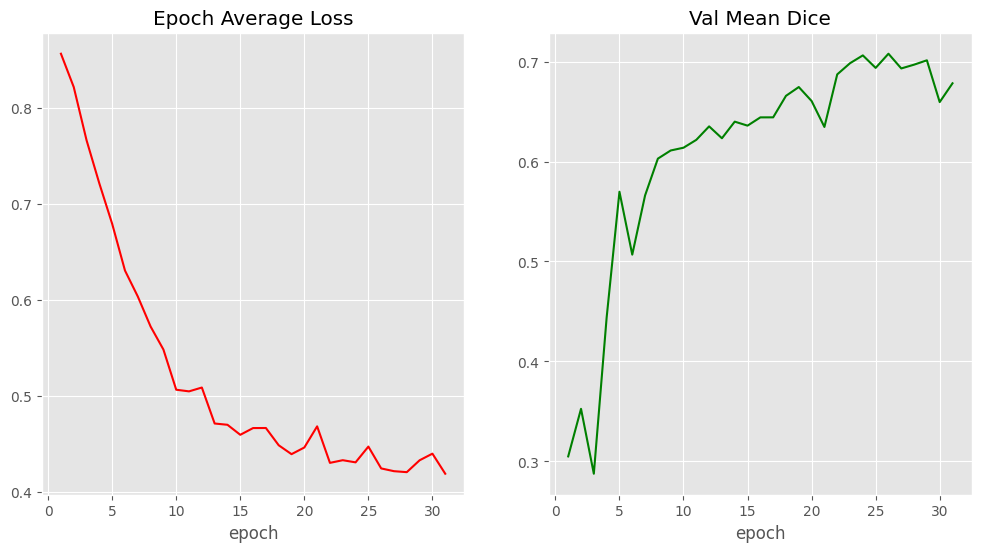

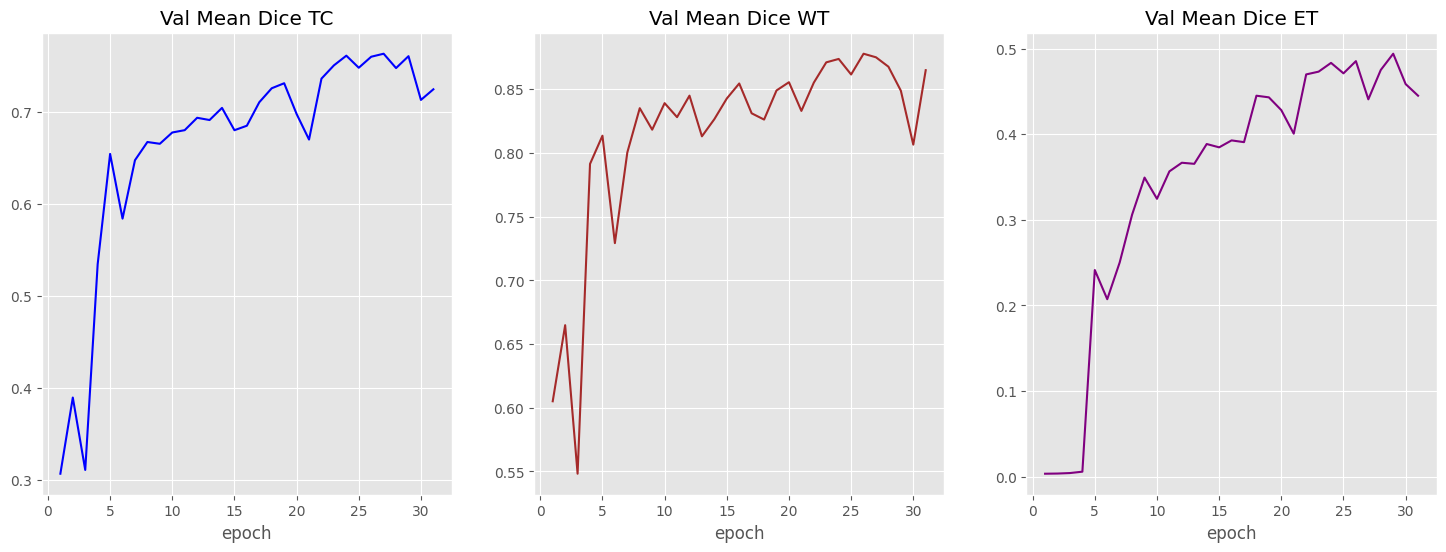

In [10]:
plt.figure('train', (12, 6))
plt.subplot(1, 2, 1)
plt.title('Epoch Average Loss')
x = [i + 1 for i in range(len(epoch_loss_values))]
y = epoch_loss_values
plt.xlabel('epoch')
plt.plot(x, y, color='red')
plt.subplot(1, 2, 2)
plt.title('Val Mean Dice')
x = [VAL_INTERVAL * (i + 1) for i in range(len(metric_values))]
y = metric_values
plt.xlabel('epoch')
plt.plot(x, y, color='green')
plt.savefig('../report/figures/val_loss_dice.jpg', dpi=300, bbox_inches=None)
plt.show()

plt.figure('train', (18, 6))
plt.subplot(1, 3, 1)
plt.title('Val Mean Dice TC')
x = [VAL_INTERVAL * (i + 1) for i in range(len(metric_values_tc))]
y = metric_values_tc
plt.xlabel('epoch')
plt.plot(x, y, color='blue')
plt.subplot(1, 3, 2)
plt.title('Val Mean Dice WT')
x = [VAL_INTERVAL * (i + 1) for i in range(len(metric_values_wt))]
y = metric_values_wt
plt.xlabel('epoch')
plt.plot(x, y, color='brown')
plt.subplot(1, 3, 3)
plt.title('Val Mean Dice ET')
x = [VAL_INTERVAL * (i + 1) for i in range(len(metric_values_et))]
y = metric_values_et
plt.xlabel('epoch')
plt.plot(x, y, color='purple')

plt.savefig('../report/figures/val_dice_scores.jpg', dpi=300, bbox_inches=None)
plt.show()

In [11]:
print(f'Final Validation Loss Value:    {epoch_loss_values[-1]:.4f}')
print(f'Final Validation Dice Mean:     {metric_values[-1]:.4f}')
print(f'Final Validation Dice TC Value: {metric_values_tc[-1]:.4f}')
print(f'Final Validation Dice WT Value: {metric_values_wt[-1]:.4f}')
print(f'Final Validation Dice ET Value: {metric_values_et[-1]:.4f}')

Final Validation Loss Value:    0.4191
Final Validation Dice Mean:     0.6783
Final Validation Dice TC Value: 0.7246
Final Validation Dice WT Value: 0.8650
Final Validation Dice ET Value: 0.4452


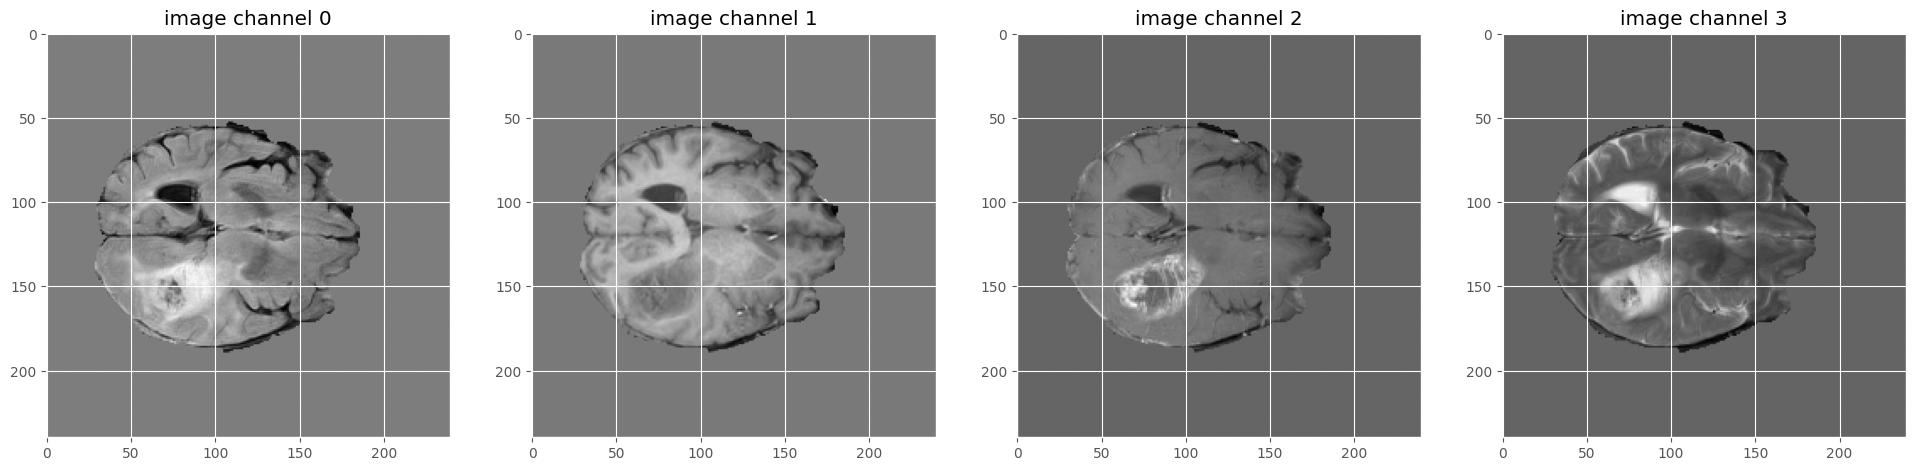

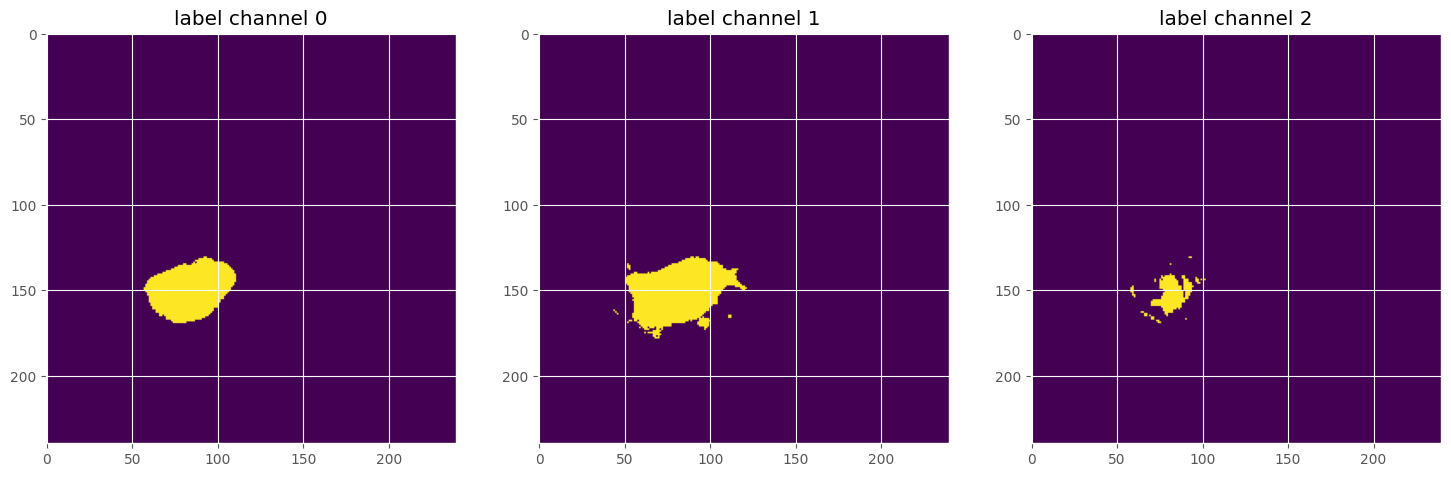

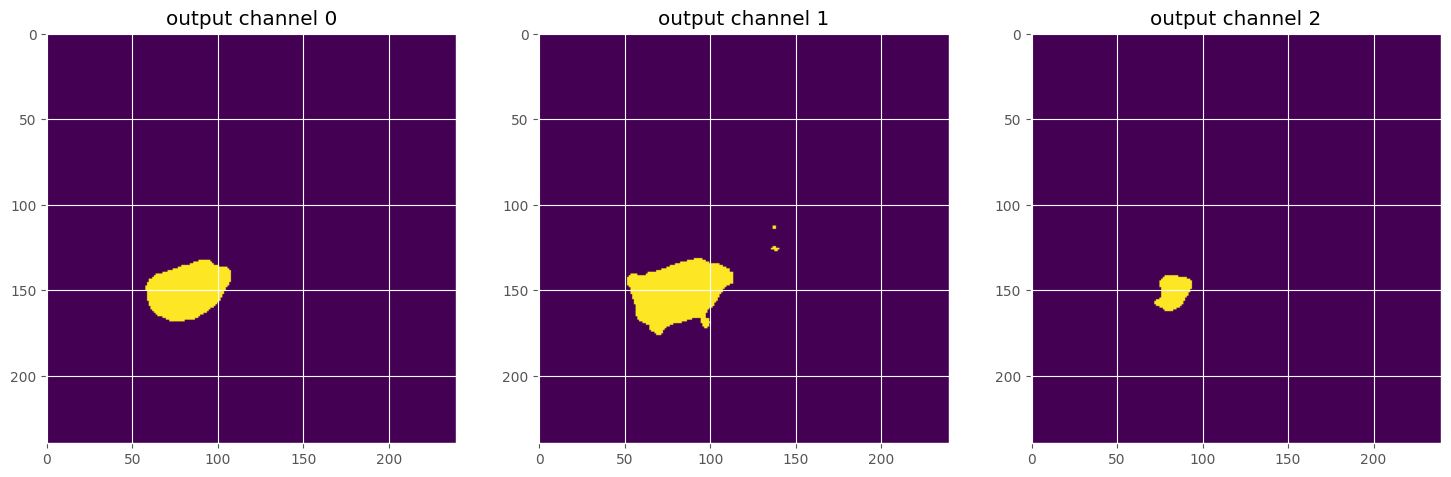

In [12]:
model.load_state_dict(torch.load(os.path.join(ROOT_DIR, 'best_metric_model.pth'), weights_only=True))
model.eval()
with torch.no_grad():
    # select one image to evaluate and visualize the model output
    val_input = val_ds[6]['image'].unsqueeze(0).to(DEVICE)
    roi_size = (ROI_SIZE)
    sw_batch_size = 4
    val_output = inference(val_input)
    val_output = post_trans(val_output[0])
    plt.figure('image', (24, 6))
    for i in range(4):
        plt.subplot(1, 4, i + 1)
        plt.title(f'image channel {i}')
        plt.imshow(val_ds[6]['image'][i, :, :, 70].detach().cpu(), cmap='gray')
    plt.savefig('../report/figures/infer_imgChan.jpg', dpi=300, bbox_inches=None)
    plt.show()
    # visualize the 3 channels label corresponding to this image
    plt.figure('label', (18, 6))
    for i in range(3):
        plt.subplot(1, 3, i + 1)
        plt.title(f'label channel {i}')
        plt.imshow(val_ds[6]['label'][i, :, :, 70].detach().cpu())
    plt.savefig('../report/figures/infer_imglab.jpg', dpi=300, bbox_inches=None)
    plt.show()
    # visualize the 3 channels model output corresponding to this image
    plt.figure('output', (18, 6))
    for i in range(3):
        plt.subplot(1, 3, i + 1)
        plt.title(f'output channel {i}')
        plt.imshow(val_output[i, :, :, 70].detach().cpu())
    plt.savefig('../report/figures/infer_outchn.jpg', dpi=300, bbox_inches=None)
    plt.show()

In [13]:
val_org_transforms = Compose(
    [
        LoadImaged(keys=['image', 'label']),
        EnsureChannelFirstd(keys=['image']),
        ConvertToMultiChannelBasedOnBratsClassesd(keys='label'),
        Orientationd(keys=['image'], axcodes='RAS'),
        Spacingd(keys=['image'], pixdim=(1.0, 1.0, 1.0), mode='bilinear'),
        NormalizeIntensityd(keys='image', nonzero=True, channel_wise=True),
    ]
)

val_org_ds = DecathlonDataset(
    root_dir=ROOT_DIR,
    task='Task01_BrainTumour',
    transform=val_org_transforms,
    section='validation',
    download=False,
    num_workers=NUM_WORKERS,
    cache_num=0,
)
val_org_loader = DataLoader(val_org_ds, batch_size=1, shuffle=False, num_workers=4)

post_transforms = Compose(
    [
        Invertd(
            keys='pred',
            transform=val_org_transforms,
            orig_keys='image',
            meta_keys='pred_meta_dict',
            orig_meta_keys='image_meta_dict',
            meta_key_postfix='meta_dict',
            nearest_interp=False,
            to_tensor=True,
            device='cpu',
        ),
        Activationsd(keys='pred', sigmoid=True),
        AsDiscreted(keys='pred', threshold=0.5),
    ]
)

In [14]:
model.load_state_dict(torch.load(os.path.join(ROOT_DIR, 'best_metric_model.pth'), weights_only=True))
model.eval()

with torch.no_grad():
    for val_data in val_org_loader:
        val_inputs = val_data['image'].to(DEVICE)
        val_data['pred'] = inference(val_inputs)
        val_data = [post_transforms(i) for i in decollate_batch(val_data)]
        val_outputs, val_labels = from_engine(['pred', 'label'])(val_data)
        dice_metric(y_pred=val_outputs, y=val_labels)
        dice_metric_batch(y_pred=val_outputs, y=val_labels)

    metric_org = dice_metric.aggregate().item()
    metric_batch_org = dice_metric_batch.aggregate()

    dice_metric.reset()
    dice_metric_batch.reset()

metric_tc, metric_wt, metric_et = metric_batch_org[0].item(), metric_batch_org[1].item(), metric_batch_org[2].item()

print(f'Metric on original image spacing: {metric_org:.4f}')
print(f'Tumor Core (TC) Dice Metric:      {metric_tc:.4f}')
print(f'Whole Tumor (WT) Dice Metric:     {metric_wt:.4f}')
print(f'Enhancing Tumor (ET) Dice Metric: {metric_et:.4f}')

Metric on original image spacing: 0.7078
Tumor Core (TC) Dice Metric:      0.7600
Whole Tumor (WT) Dice Metric:     0.8779
Enhancing Tumor (ET) Dice Metric: 0.4856


In [15]:
dummy_input = torch.randn(1, 4, 240, 240, 160).to(DEVICE)
onnx_path = os.path.join(ROOT_DIR, 'best_metric_model.onnx')
torch.onnx.export(model, dummy_input, onnx_path, verbose=False)

W0302 19:25:31.194000 1935268 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0302 19:25:31.195000 1935268 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0302 19:25:31.195000 1935268 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.
W0302 19:25:31.196000 1935268 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.


Applied 31 of general pattern rewrite rules.


ONNXProgram(
    model=
        <
            ir_version=10,
            opset_imports={'': 20},
            producer_name='pytorch',
            producer_version='2.10.0+cu128',
            domain=None,
            model_version=None,
        >
        graph(
            name=main_graph,
            inputs=(
                %"x"<FLOAT,[1,4,240,240,160]>
            ),
            outputs=(
                %"conv3d_31"<FLOAT,[1,3,240,240,160]>
            ),
            initializers=(
                %"convInit.conv.weight"<FLOAT,[16,4,3,3,3]>{TorchTensor(...)},
                %"down_layers.0.1.conv1.conv.weight"<FLOAT,[16,16,3,3,3]>{TorchTensor(...)},
                %"down_layers.0.1.conv2.conv.weight"<FLOAT,[16,16,3,3,3]>{TorchTensor(...)},
                %"down_layers.1.0.conv.weight"<FLOAT,[32,16,3,3,3]>{TorchTensor(...)},
                %"down_layers.1.1.conv1.conv.weight"<FLOAT,[32,32,3,3,3]>{TorchTensor(...)},
                %"down_layers.1.1.conv2.conv.weight"<FLOAT,[32,32

In [16]:
def onnx_infer(inputs):
    ort_inputs = {ort_session.get_inputs()[0].name: inputs.cpu().numpy()}
    ort_outs = ort_session.run(None, ort_inputs)
    return torch.Tensor(ort_outs[0]).to(inputs.device)


def predict(input):
    def _compute(input):
        return sliding_window_inference(
            inputs=input,
            roi_size=(240, 240, 160),
            sw_batch_size=1,
            predictor=onnx_infer,
            overlap=0.5,
        )

    if VAL_AMP:
        with torch.autocast('cuda'):
            return _compute(input)
    else:
        return _compute(input)

In [17]:
onnx_model_path = os.path.join(ROOT_DIR, 'best_metric_model.onnx')
ort_session = onnxruntime.InferenceSession(onnx_model_path)

for val_data in tqdm(val_loader, desc='Onnxruntime Inference Progress'):
    val_inputs, val_labels = (
        val_data['image'].to(DEVICE),
        val_data['label'].to(DEVICE),
    )

    ort_outs = predict(val_inputs)
    val_outputs = post_trans(torch.Tensor(ort_outs[0]).to(DEVICE)).unsqueeze(0)

    dice_metric(y_pred=val_outputs, y=val_labels)
    dice_metric_batch(y_pred=val_outputs, y=val_labels)
onnx_metric = dice_metric.aggregate().item()
onnx_metric_batch = dice_metric_batch.aggregate()
onnx_metric_tc = onnx_metric_batch[0].item()
onnx_metric_wt = onnx_metric_batch[1].item()
onnx_metric_et = onnx_metric_batch[2].item()

print(f'onnx metric:    {onnx_metric:.4f}')
print(f'onnx_metric_tc: {onnx_metric_tc:.4f}')
print(f'onnx_metric_wt: {onnx_metric_wt:.4f}')
print(f'onnx_metric_et: {onnx_metric_et:.4f}')

Onnxruntime Inference Progress: 100%|██████████████████| 96/96 [04:54<00:00,  3.06s/it]

onnx metric:    0.6940
onnx_metric_tc: 0.7416
onnx_metric_wt: 0.8671
onnx_metric_et: 0.4732


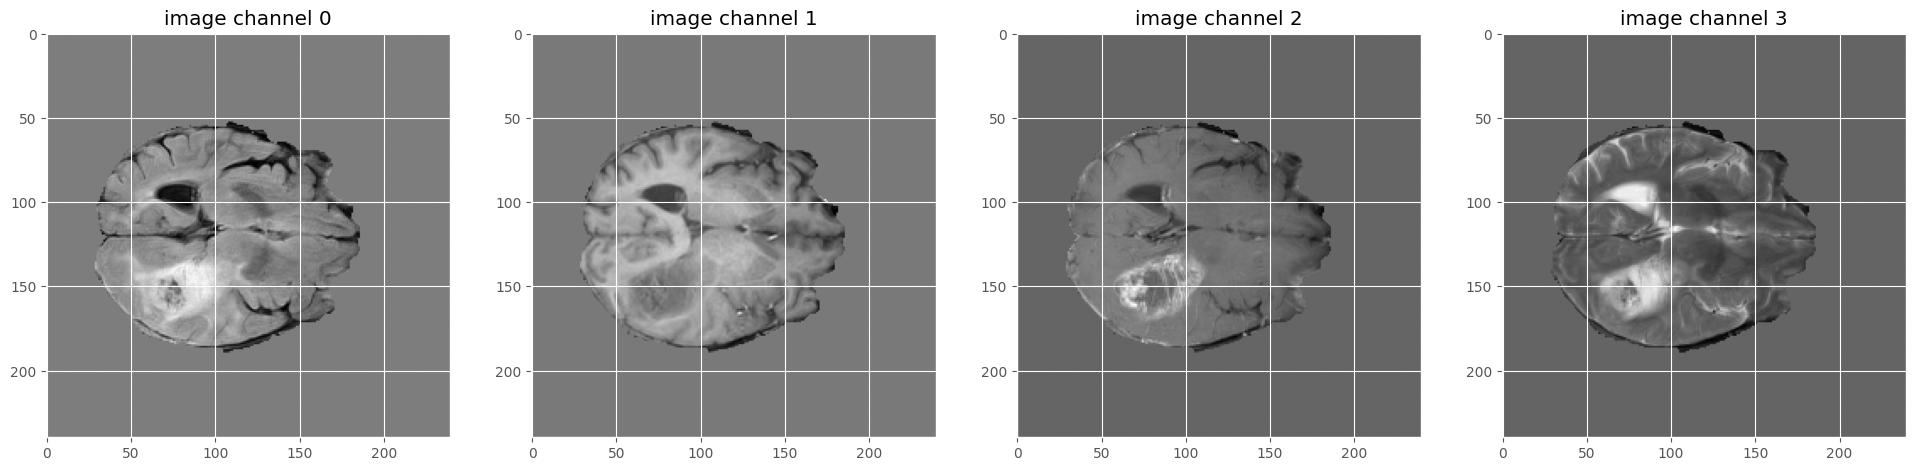

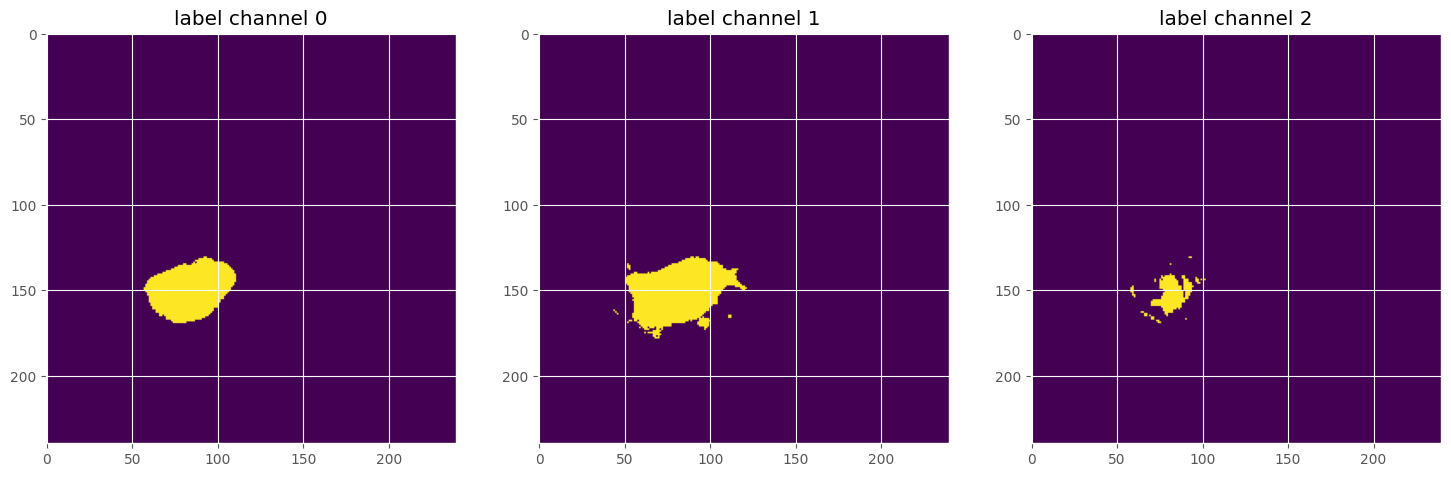

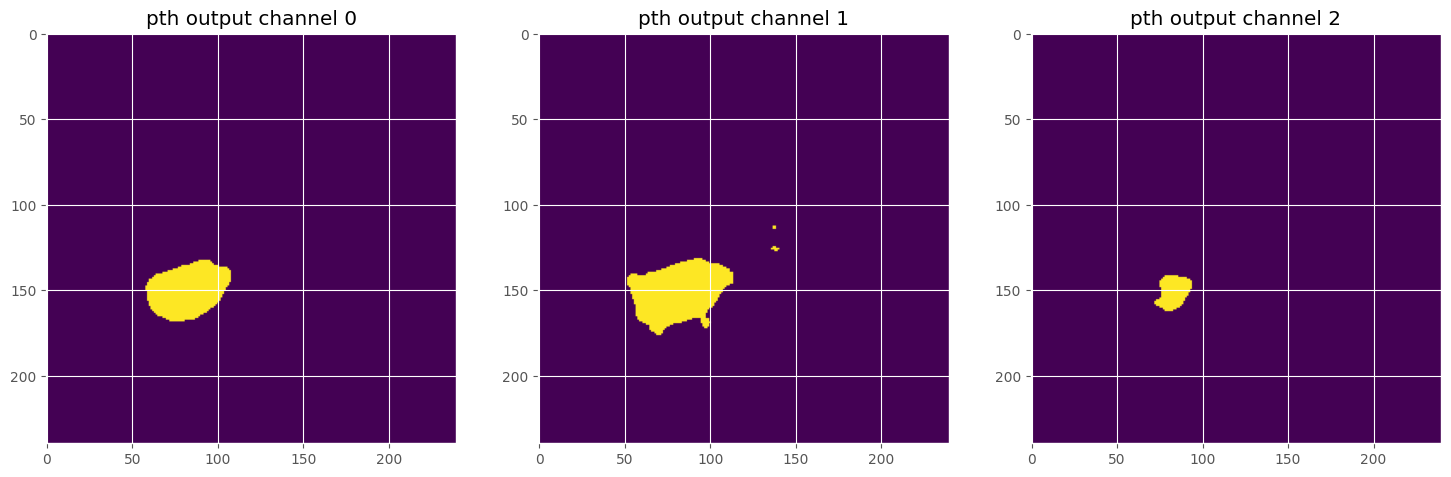

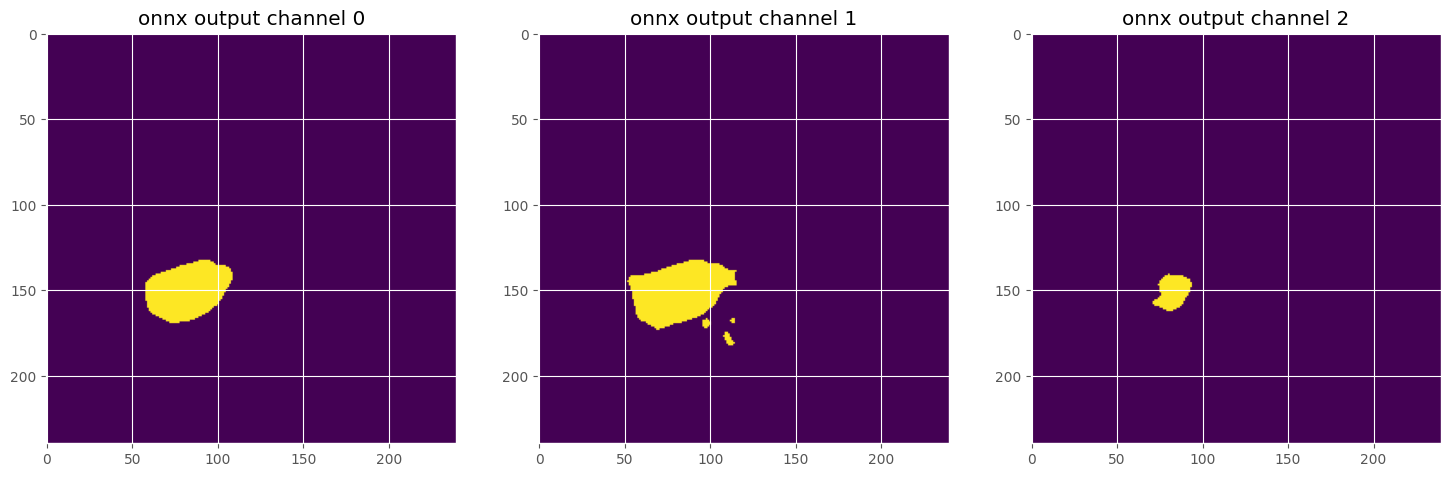

In [19]:
onnx_model_path = os.path.join(ROOT_DIR, 'best_metric_model.onnx')
ort_session = onnxruntime.InferenceSession(onnx_model_path)
model.load_state_dict(torch.load(os.path.join(ROOT_DIR, 'best_metric_model.pth'), weights_only=True))
model.eval()

with torch.no_grad():
    # select one image to evaluate and visualize the model output
    val_input = val_ds[6]['image'].unsqueeze(0).to(DEVICE)
    val_output = inference(val_input)
    val_output = post_trans(val_output[0])
    ort_output = predict(val_input)
    ort_output = post_trans(torch.Tensor(ort_output[0]).to(DEVICE)).unsqueeze(0)
    plt.figure('image', (24, 6))
    for i in range(4):
        plt.subplot(1, 4, i + 1)
        plt.title(f'image channel {i}')
        plt.imshow(val_ds[6]['image'][i, :, :, 70].detach().cpu(), cmap='gray')
    plt.savefig('../report/figures/onnx_imgChan.jpg', dpi=300, bbox_inches=None)
    plt.show()
    # visualize the 3 channels label corresponding to this image
    plt.figure('label', (18, 6))
    for i in range(3):
        plt.subplot(1, 3, i + 1)
        plt.title(f'label channel {i}')
        plt.imshow(val_ds[6]['label'][i, :, :, 70].detach().cpu())
    plt.savefig('../report/figures/onnx_outchan.jpg', dpi=300, bbox_inches=None)
    plt.show()
    # visualize the 3 channels model output corresponding to this image
    plt.figure('output', (18, 6))
    for i in range(3):
        plt.subplot(1, 3, i + 1)
        plt.title(f'pth output channel {i}')
        plt.imshow(val_output[i, :, :, 70].detach().cpu())
    plt.savefig('../report/figures/onnx_outlab.jpg')
    plt.show()
    plt.figure('output', (18, 6))
    for i in range(3):
        plt.subplot(1, 3, i + 1)
        plt.title(f'onnx output channel {i}')
        plt.imshow(ort_output[0, i, :, :, 70].detach().cpu())
    plt.savefig('../report/figures/onnx_pthOut.jpg', dpi=300, bbox_inches=None)
    plt.show()